# 05 — Deep Error Analysis

**Goal:** Understand WHERE and WHY the model makes errors.

**What we analyze:**
1. Load predictions from both models
2. Segment analysis: error rate by client characteristics
3. FP vs FN deep dive: what makes errors different?
4. Worst-performing segments: which clients should we worry about?
5. Feature importance for errors: what drives mistakes?

**Note:** Threshold selection is in notebook 04. Here we use threshold=0.5 for analysis.

**Run:** `docker compose exec airflow-scheduler jupyter notebook notebooks/05_error_analysis.ipynb --allow-root`

In [9]:
import sys
from pathlib import Path

# Handle both Docker (/opt/airflow) and local execution
docker_path = Path('/opt/airflow')
if docker_path.exists():
    sys.path.insert(0, str(docker_path))
else:
    ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    sys.path.insert(0, str(ROOT))

# Auto-install psycopg2 if missing
try:
    import psycopg2
except ImportError:
    print('Installing psycopg2-binary...')
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'psycopg2-binary'])
    print('✅ psycopg2-binary installed')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from src.config import get_db_engine, TrainingConfig, ARTIFACTS_DIR
from src.data.queries import get_feature_dataset
from src.models.scoring.train import get_feature_matrix
from src.models.scoring.artifacts import ScoringArtifact

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Modules loaded')

✅ Modules loaded


## 1. Load data and make predictions

In [10]:
# Load validation data with raw features for segment analysis
engine = get_db_engine()
train, val, test = get_feature_dataset(engine, TrainingConfig.TRAIN_END_DATE, TrainingConfig.VAL_END_DATE)

# Join with raw.applications to get raw features for segment analysis
from sqlalchemy import text
with engine.connect() as conn:
    raw_features = pd.read_sql(text("""
        SELECT application_id, credit_score, loan_amount, income, dti_ratio, interest_rate, employment_years, num_open_accounts
        FROM raw.applications
    """), conn)

val = val.merge(raw_features, on='application_id', how='left')

print(f'✅ Validation set: {len(val)} rows, default rate: {val[TrainingConfig.TARGET_COL].mean():.3%}')
print(f'✅ Added raw features: {list(raw_features.columns[1:])}')

# Load models
models = {}
for segment in ['with_history', 'cold_start']:
    path = ARTIFACTS_DIR / segment
    if (path / 'model.pkl').exists():
        models[segment] = ScoringArtifact.load(path)
        print(f'✅ Loaded {segment}: {models[segment].model_type}')

if not models:
    raise RuntimeError('❌ No models found!')

✅ Validation set: 64013 rows, default rate: 9.332%
✅ Added raw features: ['credit_score', 'loan_amount', 'income', 'dti_ratio', 'interest_rate', 'employment_years', 'num_open_accounts']
✅ Loaded with_history: catboost
✅ Loaded cold_start: catboost


c:\Users\pc\anaconda1\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.4.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\pc\anaconda1\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifierCV from version 1.4.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [11]:
# Split by segment and predict
val_with_hist = val[val['avg_days_overdue_90d'].notna() & (val['avg_days_overdue_90d'] != 0)]
val_cold = val[val['avg_days_overdue_90d'].isna() | (val['avg_days_overdue_90d'] == 0)]

results = []
THRESHOLD = 0.5  # Fixed threshold for analysis

for segment, artifact in models.items():
    df = val_with_hist if segment == 'with_history' else val_cold
    if len(df) == 0:
        continue
    
    X, _ = get_feature_matrix(df, artifact.feature_names)
    X = X.fillna(pd.Series(artifact.feature_medians))
    pred_proba = artifact.predict_proba(X)
    
    df = df.copy()
    df['segment'] = segment
    df['y_true'] = df[TrainingConfig.TARGET_COL].astype(int)
    df['y_pred_proba'] = pred_proba
    df['y_pred'] = (pred_proba >= THRESHOLD).astype(int)
    df['error'] = (df['y_pred'] != df['y_true']).astype(int)
    
    # Classify error types
    df['error_type'] = 'correct'
    df.loc[(df['y_pred']==1) & (df['y_true']==0), 'error_type'] = 'FP'
    df.loc[(df['y_pred']==0) & (df['y_true']==1), 'error_type'] = 'FN'
    
    results.append(df)
    print(f'{segment}: {len(df)} samples, error rate: {df["error"].mean():.2%}')

all_pred = pd.concat(results)
print(f'\n📊 Total: {len(all_pred)} clients, error rate: {all_pred["error"].mean():.2%}')

with_history: 9323 samples, error rate: 5.27%
cold_start: 54690 samples, error rate: 8.58%

📊 Total: 64013 clients, error rate: 8.10%


## 2. Confusion Matrix & Error Types

📊 Confusion Matrix:
   TN: 57967 (90.6%) - Correctly rejected
   FP:    72 (0.1%) - False alarm (rejected good client)
   FN:  5112 (8.0%) - Missed default (approved defaulter)
   TP:   862 (1.3%) - Correctly approved

📈 Metrics:
   Precision: 92.29% (of predicted defaults, how many are real)
   Recall: 14.43% (of actual defaults, how many we catch)
   FPR: 0.12% (false alarm rate)
   FNR: 85.57% (miss rate)


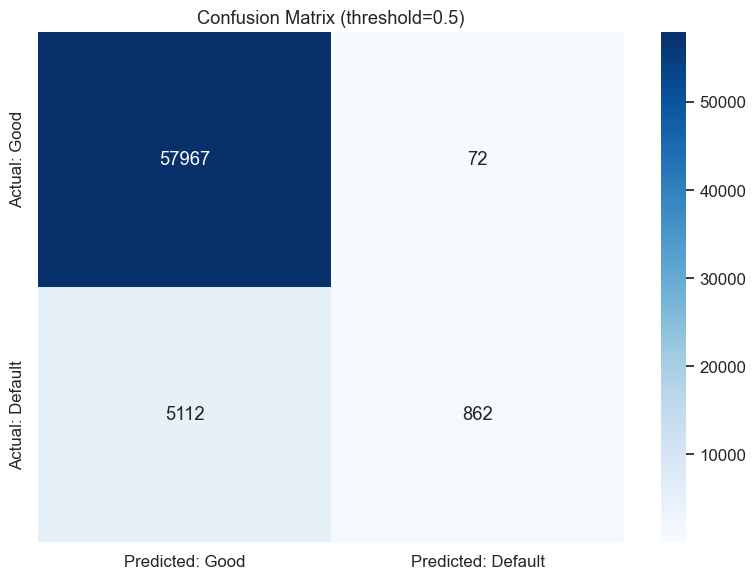

In [12]:
cm = confusion_matrix(all_pred['y_true'], all_pred['y_pred'])
tn, fp, fn, tp = cm.ravel()

print('📊 Confusion Matrix:')
print(f'   TN: {tn:5d} ({tn/len(all_pred):.1%}) - Correctly rejected')
print(f'   FP: {fp:5d} ({fp/len(all_pred):.1%}) - False alarm (rejected good client)')
print(f'   FN: {fn:5d} ({fn/len(all_pred):.1%}) - Missed default (approved defaulter)')
print(f'   TP: {tp:5d} ({tp/len(all_pred):.1%}) - Correctly approved')

print(f'\n📈 Metrics:')
print(f'   Precision: {tp/(tp+fp):.2%} (of predicted defaults, how many are real)')
print(f'   Recall: {tp/(tp+fn):.2%} (of actual defaults, how many we catch)')
print(f'   FPR: {fp/(fp+tn):.2%} (false alarm rate)')
print(f'   FNR: {fn/(fn+tp):.2%} (miss rate)')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Good', 'Predicted: Default'],
            yticklabels=['Actual: Good', 'Actual: Default'])
plt.title(f'Confusion Matrix (threshold={THRESHOLD})')
plt.tight_layout()
plt.show()

## 3. Segment Analysis: Error Rate by Client Characteristics

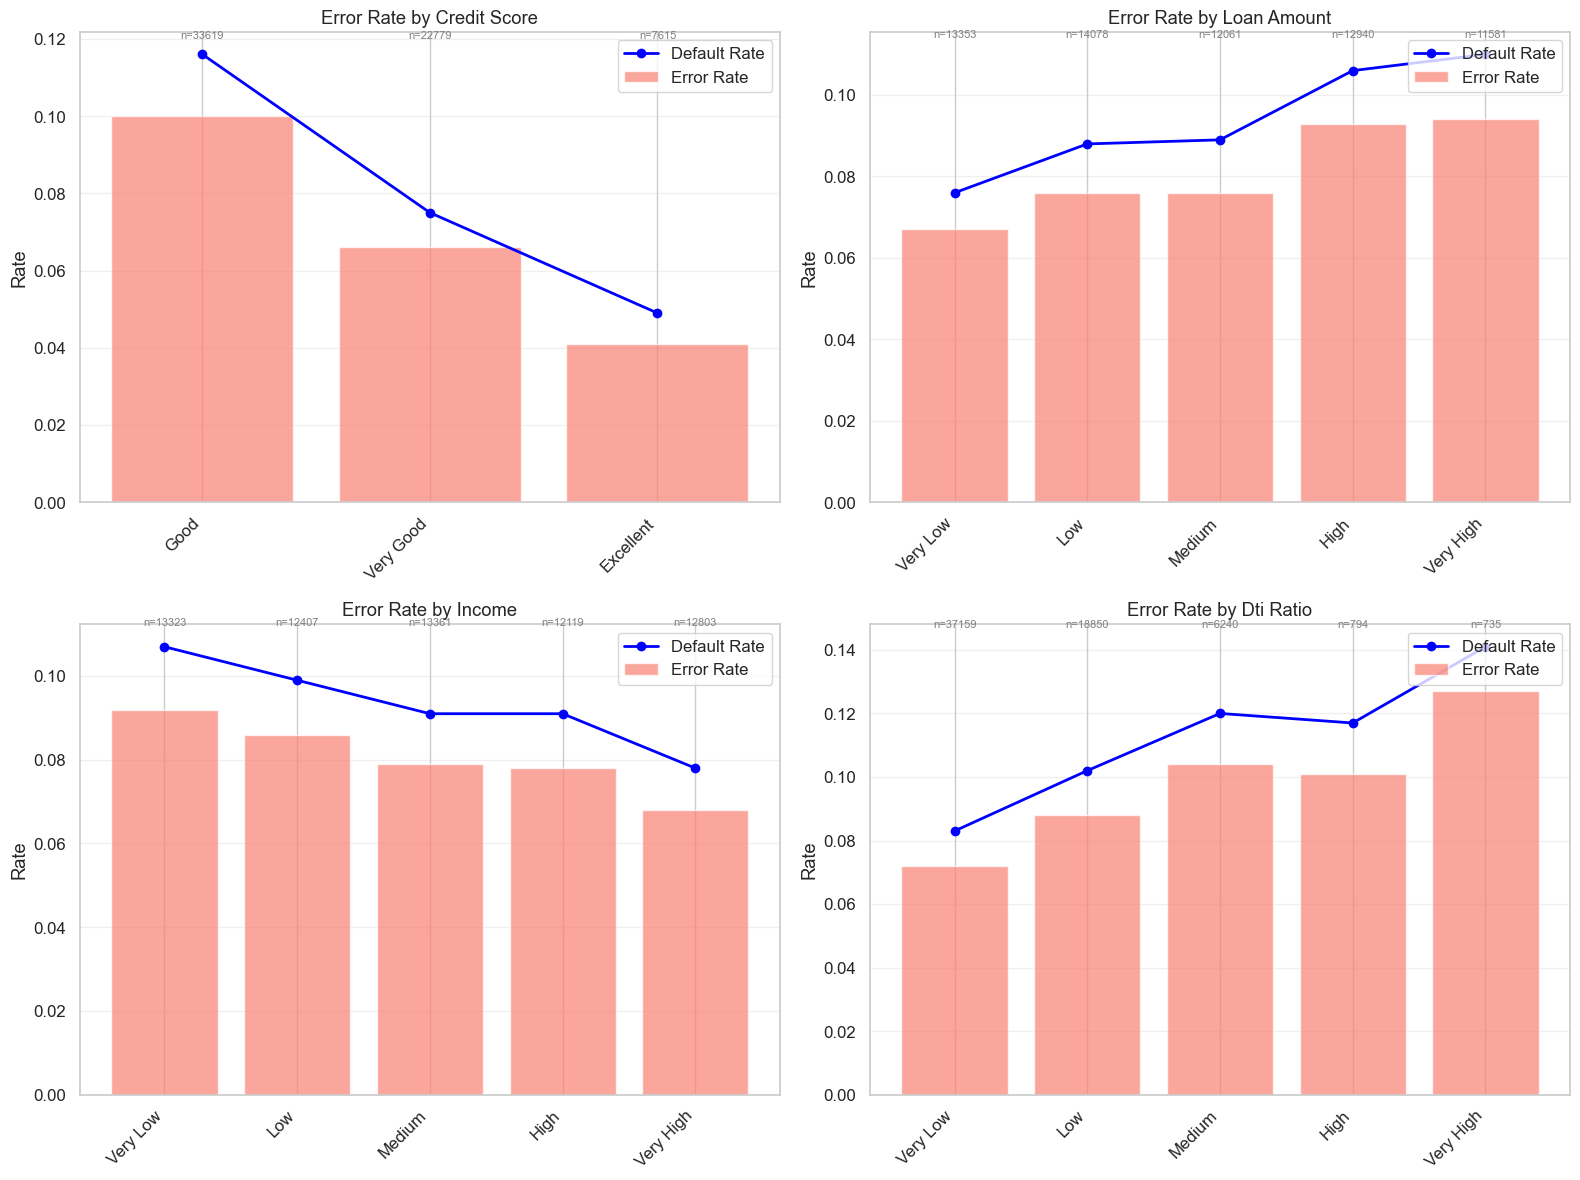


📊 Key Insights:
   - Compare error rate vs default rate: if error rate >> default rate, model struggles
   - Look for segments with high error rate AND high count (many errors)
   - Check if error rate correlates with risk (should decrease for risky clients)


In [13]:
# Deep segment analysis
segment_features = [
    ('credit_score', [0, 600, 650, 700, 750, 900], ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']),
    ('loan_amount', None, ['Very Low', 'Low', 'Medium', 'High', 'Very High']),  # quintiles
    ('income', None, ['Very Low', 'Low', 'Medium', 'High', 'Very High']),
    ('dti_ratio', [0, 20, 30, 40, 50, 100], ['Very Low', 'Low', 'Medium', 'High', 'Very High']),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (feature, bins, labels) in enumerate(segment_features):
    if feature not in all_pred.columns:
        continue
    
    if bins is None:
        all_pred[f'{feature}_bucket'] = pd.qcut(all_pred[feature], q=5, labels=labels, duplicates='drop')
    else:
        all_pred[f'{feature}_bucket'] = pd.cut(all_pred[feature], bins=bins, labels=labels)
    
    segment_stats = all_pred.groupby(f'{feature}_bucket', observed=True).agg({
        'error': 'mean',
        'y_true': ['count', 'mean']
    }).round(3)
    
    segment_stats.columns = ['error_rate', 'count', 'default_rate']
    
    # Plot
    ax = axes[idx]
    x = range(len(segment_stats))
    ax.bar(x, segment_stats['error_rate'], color='salmon', alpha=0.7, label='Error Rate')
    ax.plot(x, segment_stats['default_rate'], 'o-', color='blue', linewidth=2, label='Default Rate')
    ax.set_xticks(x)
    ax.set_xticklabels(segment_stats.index, rotation=45, ha='right')
    ax.set_ylabel('Rate')
    ax.set_title(f'Error Rate by {feature.replace("_", " ").title()}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count labels
    for i, count in enumerate(segment_stats['count']):
        ax.text(i, segment_stats['error_rate'].max() + 0.02, f'n={int(count)}', 
                ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print('\n📊 Key Insights:')
print('   - Compare error rate vs default rate: if error rate >> default rate, model struggles')
print('   - Look for segments with high error rate AND high count (many errors)')
print('   - Check if error rate correlates with risk (should decrease for risky clients)')

## 4. FP vs FN: What Makes Errors Different?

In [14]:
# Deep dive into FP vs FN
fp_samples = all_pred[all_pred['error_type'] == 'FP']
fn_samples = all_pred[all_pred['error_type'] == 'FN']
correct_samples = all_pred[all_pred['error_type'] == 'correct']

print(f'❌ False Positives (FP): {len(fp_samples)} ({len(fp_samples)/len(all_pred):.1%})')
print(f'   → Rejected good clients (lost business)')
print(f'\n❌ False Negatives (FN): {len(fn_samples)} ({len(fn_samples)/len(all_pred):.1%})')
print(f'   → Approved defaulters (financial loss)')

# Compare characteristics
features_to_compare = [
    'loan_to_income', 'credit_score', 'dti_ratio', 'interest_rate', 
    'loan_amount', 'income', 'employment_years', 'num_open_accounts'
]

print(f'\n📊 Feature Comparison (mean values):')
print(f'{"Feature":<25} {"FP (rejected good)":>20} {"FN (approved bad)":>20} {"Correct":>15}')
print('-' * 85)

for feat in features_to_compare:
    if feat in all_pred.columns:
        fp_mean = fp_samples[feat].mean()
        fn_mean = fn_samples[feat].mean()
        correct_mean = correct_samples[feat].mean()
        print(f'{feat:<25} {fp_mean:>20.2f} {fn_mean:>20.2f} {correct_mean:>15.2f}')

❌ False Positives (FP): 72 (0.1%)
   → Rejected good clients (lost business)

❌ False Negatives (FN): 5112 (8.0%)
   → Approved defaulters (financial loss)

📊 Feature Comparison (mean values):
Feature                     FP (rejected good)    FN (approved bad)         Correct
-------------------------------------------------------------------------------------
loan_to_income                            0.22                 0.27            1.07
credit_score                            704.36               694.68          705.63
dti_ratio                                18.57                20.87           19.37
loan_amount                           15562.85             16083.57        14851.05
income                                80472.25             73079.95        79742.73


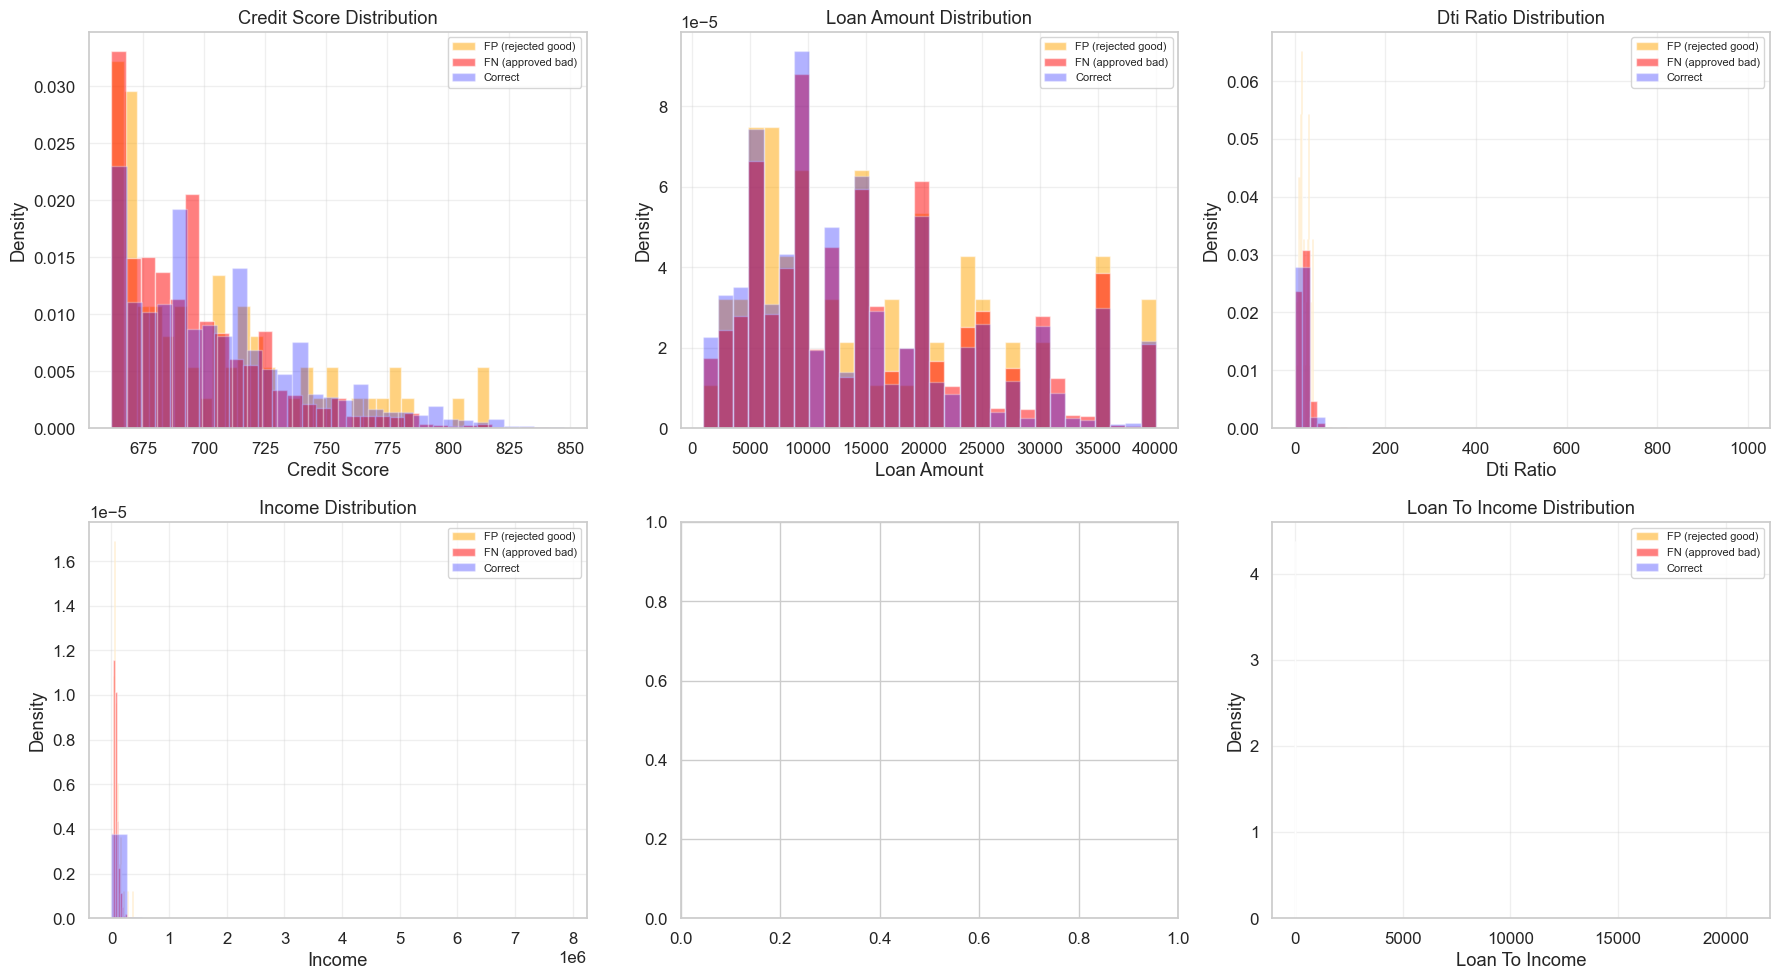


💡 Interpretation:
   - If FP and FN have different distributions → model treats them differently
   - Look for features where FP/FN overlap with correct samples (hard cases)
   - Features with clear separation → model uses them well


In [15]:
# Visualization: FP vs FN distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

key_features = ['credit_score', 'loan_amount', 'dti_ratio', 'income', 'interest_rate', 'loan_to_income']

for idx, feat in enumerate(key_features):
    if feat not in all_pred.columns:
        continue
    
    ax = axes[idx]
    ax.hist(fp_samples[feat], bins=30, alpha=0.5, label='FP (rejected good)', color='orange', density=True)
    ax.hist(fn_samples[feat], bins=30, alpha=0.5, label='FN (approved bad)', color='red', density=True)
    ax.hist(correct_samples[feat], bins=30, alpha=0.3, label='Correct', color='blue', density=True)
    ax.set_xlabel(feat.replace('_', ' ').title())
    ax.set_ylabel('Density')
    ax.set_title(f'{feat.replace("_", " ").title()} Distribution')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n💡 Interpretation:')
print('   - If FP and FN have different distributions → model treats them differently')
print('   - Look for features where FP/FN overlap with correct samples (hard cases)')
print('   - Features with clear separation → model uses them well')

## 5. Worst-Performing Segments: Who Should We Worry About?

📊 Worst-Performing Segments (error rate > 30% AND count >= 100):

   No segments with error rate > 30%


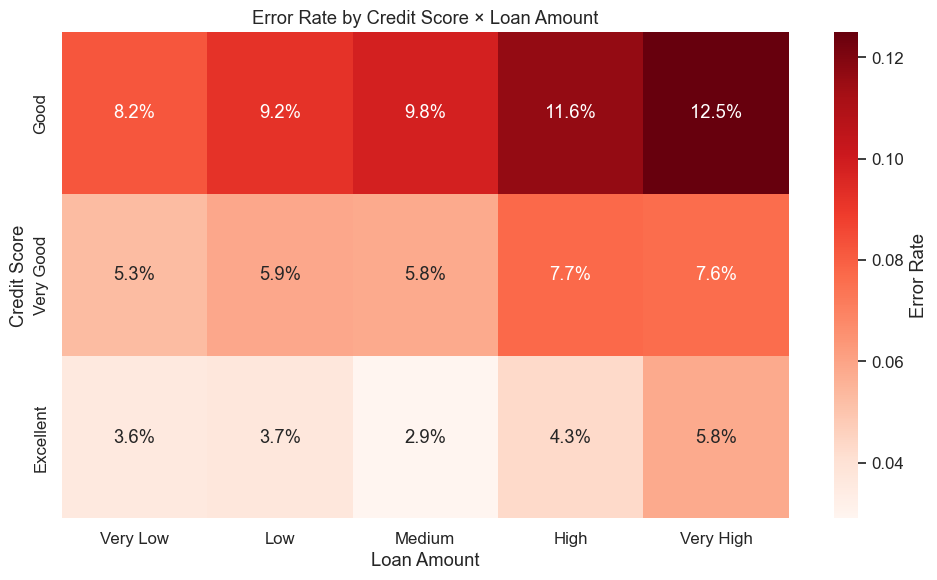

In [16]:
# Find worst-performing segments
all_pred['credit_bucket'] = pd.cut(all_pred['credit_score'], 
                                    bins=[0, 600, 650, 700, 750, 900],
                                    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])
all_pred['loan_bucket'] = pd.qcut(all_pred['loan_amount'], q=5, 
                                   labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
all_pred['income_bucket'] = pd.qcut(all_pred['income'], q=5,
                                     labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Cross-tabulation: credit score × loan amount
cross_errors = all_pred.groupby(['credit_bucket', 'loan_bucket'], observed=True).agg({
    'error': ['mean', 'count'],
    'y_true': 'mean'
}).round(3)

cross_errors.columns = ['error_rate', 'count', 'default_rate']
cross_errors = cross_errors[cross_errors['count'] >= 100]  # Filter small segments

print('📊 Worst-Performing Segments (error rate > 30% AND count >= 100):')
print()

worst_segments = cross_errors[cross_errors['error_rate'] > 0.30].sort_values('error_rate', ascending=False)

if len(worst_segments) > 0:
    for (credit, loan), row in worst_segments.head(10).iterrows():
        print(f'   Credit={credit:<12} Loan={loan:<12} | '
              f'Error: {row["error_rate"]:.1%} | Default: {row["default_rate"]:.1%} | n={int(row["count"])}')
else:
    print('   No segments with error rate > 30%')

# Heatmap
pivot_errors = cross_errors['error_rate'].unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_errors, annot=True, fmt='.1%', cmap='Reds', cbar_kws={'label': 'Error Rate'})
plt.title('Error Rate by Credit Score × Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

## 6. Prediction Confidence Analysis

📊 Error Rate by Prediction Confidence:

   Very Low     | Error: 18.2% | n=12814
   Low          | Error: 9.9% | n=15259
   Medium       | Error: 6.2% | n=12807
   High         | Error: 3.7% | n=12098
   Very High    | Error: 0.9% | n=11035


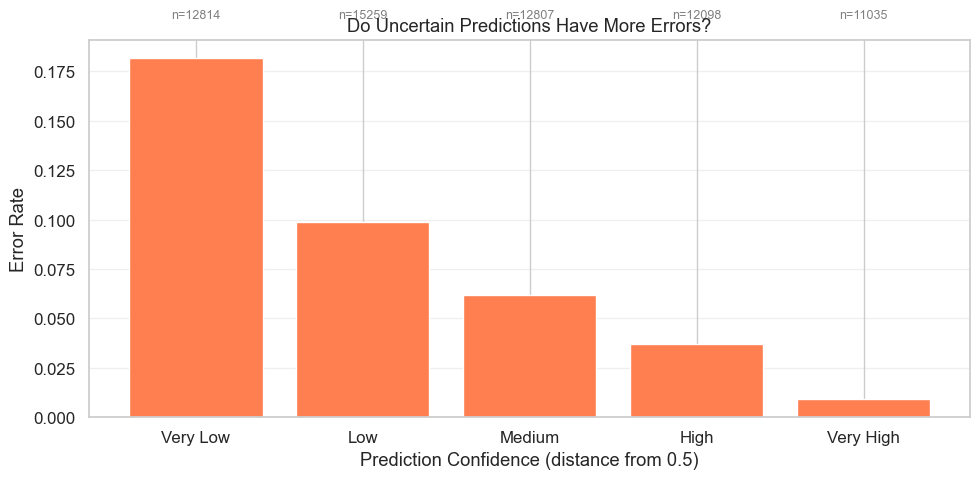


💡 Insight:
   - If low confidence → high error rate: model is uncertain about hard cases
   - Consider manual review for low-confidence predictions


In [17]:
# Analyze errors by prediction confidence
all_pred['confidence'] = np.abs(all_pred['y_pred_proba'] - 0.5)  # Distance from 0.5
all_pred['confidence_bucket'] = pd.qcut(all_pred['confidence'], q=5,
                                         labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

confidence_stats = all_pred.groupby('confidence_bucket', observed=True).agg({
    'error': 'mean',
    'y_true': 'count'
}).round(3)

confidence_stats.columns = ['error_rate', 'count']

print('📊 Error Rate by Prediction Confidence:')
print()
for bucket, row in confidence_stats.iterrows():
    print(f'   {bucket:<12} | Error: {row["error_rate"]:.1%} | n={int(row["count"])}')

plt.figure(figsize=(10, 5))
plt.bar(confidence_stats.index, confidence_stats['error_rate'], color='coral')
plt.xlabel('Prediction Confidence (distance from 0.5)')
plt.ylabel('Error Rate')
plt.title('Do Uncertain Predictions Have More Errors?')
plt.grid(True, alpha=0.3, axis='y')

for i, count in enumerate(confidence_stats['count']):
    plt.text(i, confidence_stats['error_rate'].max() + 0.02, f'n={int(count)}',
             ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print('\n💡 Insight:')
print('   - If low confidence → high error rate: model is uncertain about hard cases')
print('   - Consider manual review for low-confidence predictions')

## 7. Summary & Recommendations

In [18]:
print('='*80)
print('📋 ERROR ANALYSIS SUMMARY')
print('='*80)

print(f'\n✅ Overall Performance (threshold={THRESHOLD}):')
print(f'   Error rate: {all_pred["error"].mean():.2%}')
print(f'   Precision: {tp/(tp+fp):.2%} | Recall: {tp/(tp+fn):.2%}')
print(f'   FP: {len(fp_samples)} ({len(fp_samples)/len(all_pred):.1%}) | FN: {len(fn_samples)} ({len(fn_samples)/len(all_pred):.1%})')

print(f'\n📊 By Segment:')
for seg in ['with_history', 'cold_start']:
    df_seg = all_pred[all_pred['segment'] == seg]
    if len(df_seg) > 0:
        print(f'   {seg:<20} | Error: {df_seg["error"].mean():.2%} | Default: {df_seg["y_true"].mean():.2%} | n={len(df_seg)}')

print(f'\n🔍 Worst Segments (error rate > 30%):')
if len(worst_segments) > 0:
    for (credit, loan), row in worst_segments.head(5).iterrows():
        print(f'   Credit={credit}, Loan={loan}: error={row["error_rate"]:.1%}, n={int(row["count"])}')
else:
    print('   None')

print(f'\n💡 Recommendations:')
print('   1. Focus on worst-performing segments (high error + high count)')
print('   2. If FP >> FN: threshold too low → increase threshold')
print('   3. If FN >> FP: threshold too high → decrease threshold')
print('   4. Consider segment-specific models for worst segments')
print('   5. Add features that differentiate FP/FN from correct predictions')
print('   6. Manual review for low-confidence predictions')

print('\n' + '='*80)
print('✅ Deep error analysis complete!')
print('='*80)

📋 ERROR ANALYSIS SUMMARY

✅ Overall Performance (threshold=0.5):
   Error rate: 8.10%
   Precision: 92.29% | Recall: 14.43%
   FP: 72 (0.1%) | FN: 5112 (8.0%)

📊 By Segment:
   with_history         | Error: 5.27% | Default: 13.74% | n=9323
   cold_start           | Error: 8.58% | Default: 8.58% | n=54690

🔍 Worst Segments (error rate > 30%):
   None

💡 Recommendations:
   1. Focus on worst-performing segments (high error + high count)
   2. If FP >> FN: threshold too low → increase threshold
   3. If FN >> FP: threshold too high → decrease threshold
   4. Consider segment-specific models for worst segments
   5. Add features that differentiate FP/FN from correct predictions
   6. Manual review for low-confidence predictions

✅ Deep error analysis complete!
